In [1]:
# best models: offline random forest / or combine random forest
import numpy as np
from national.data_refresh.src import utils
import matplotlib as mpl
from national.data_refresh.src import params
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None

def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    return data

fb_cols = params.fb_vars
bg_cols = params.bg_cols
model_specs = {'online': fb_cols+['conti'], 'offline': bg_cols, 'combined': fb_cols + bg_cols}


In [2]:
latest_contrl = False
missing_contrl = True
rolling_contrl = True
del_country_contrl = False
indicator = 'internet'


In [3]:
df_fb_data = pd.read_csv(params.dropbox_path/f'data/fb_data/fb_all_sd_monthly{"_rolling" if rolling_contrl else ""}.csv')


In [9]:
# don't need to re-execute if the result files are already there
for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
    for model_type in ['offline', 'combined', 'online']:
        for indicator in ['internet', 'mobile']:
            for outcome_var in ['ggi','wom','men']:
        
                df_res = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year','month', 'true', 'pred'])
        
                for year in range(2019, 2025):
        
                    df_model = pd.read_csv(params.dropbox_data_path / f'combined_data/{indicator}/year_align/combined_multiple_years_no_missing_fb_aligned_{round(year)}.csv')
        
                    
                    df_model.drop(columns=fb_cols, inplace=True)
                    df_model = df_model.merge(df_fb_data, left_on=['iso3', 'align_year'],right_on=['iso3','survey_year'], how='left')
                    df_model = df_model.dropna(subset=params.bg_cols+params.fb_vars)
                    #print(year, df_model.isnull().sum().sum()/df_model.shape[0]/df_model.shape[1])
                    
                    model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
                    model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
        
                    # load the model
                    temp = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year','month', 'true', 'pred'])
                    model = load_model(model_filepath)
        
                    for month in range(1, 13) if year != 2024 else range(1, 7):
                        df_model_month = df_model.loc[df_model['month']==month]
        
                        countries = df_model_month['iso3'].tolist()
                        X = preprocess_data(df_model_month[model_specs[model_type]])
                        X = X[model.feature_names_in_]
                        y_pred = model.predict(X)
        
                        for ind in range(len(y_pred)):
                            true_value = df_model.loc[(df_model[f'{indicator}_year']==year) & (df_model[f'iso3']==countries[ind]), f'{indicator}_{outcome_var}']
                            true_value = true_value.values[0] if len(true_value) > 0 else None
                            temp.loc[len(temp), :] = [indicator,outcome_var,model_type,countries[ind], year,month, true_value, y_pred[ind]]
        
                        temp = temp.groupby(['indicator','outcome_var','model_type','iso3','year','month'], as_index=False).mean() # some countries have multiple entries but the results are the same
        
                    df_res = pd.concat([df_res, temp], axis=0)
                res_folder_path = params.dropbox_data_path.parent / f'results/pred_by_year_and_month{"_rolling" if rolling_contrl else ""}/{model_folder}/{model_type}'
                if not os.path.exists(res_folder_path):
                    os.makedirs(res_folder_path)
                df_res.to_csv(res_folder_path/f'{indicator}_{outcome_var}.csv', index=False)



# visualisations

In [6]:
rolling_contrl

True

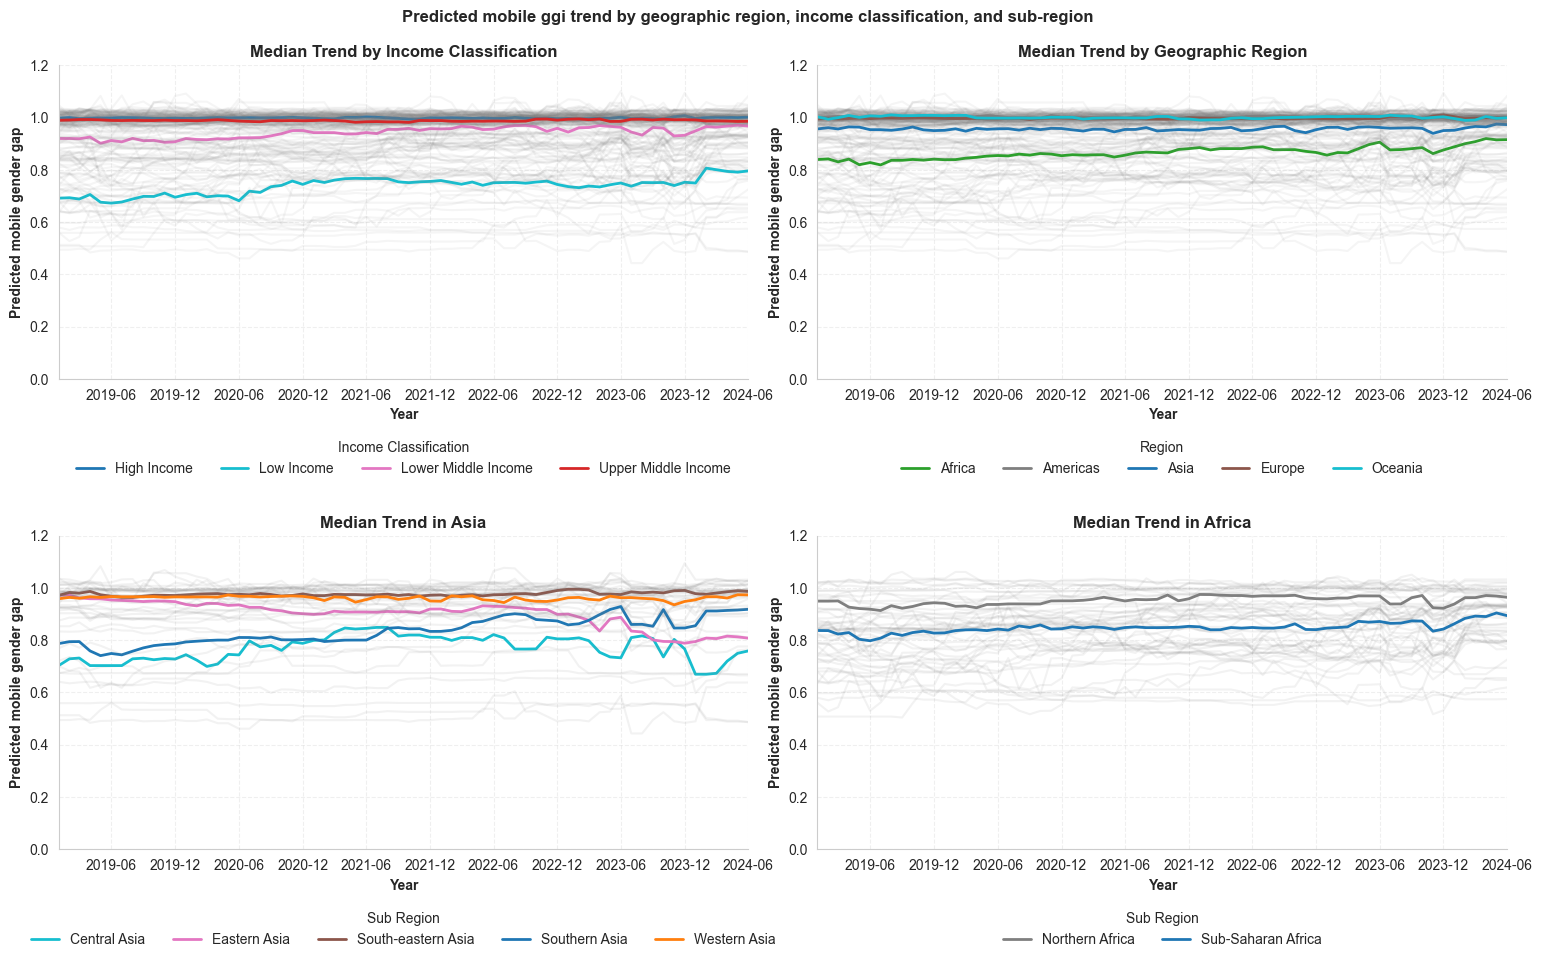

In [7]:
start_year = 2019
end_year = 2024
indicator = 'mobile'
outcome_var = 'ggi'
#for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
for model_folder in ['18_plus']:
    df_res = pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_and_month{"_rolling" if rolling_contrl else ""}/{model_folder}/online/{indicator}_{outcome_var}.csv')
    
    df_plot = df_res.pivot(index = ['iso3'],columns = ['year','month'],values=['pred']).reset_index()
    df_plot.columns = [f'{x}_{round(y)}_{round(m)}' if y != '' else f'{x}' for x,y,m in df_plot.columns]
    
    # mark income level and type
    
    income_year = 2022
    
    df_plot['continent'] = [utils.get_continent_from_iso3(iso3) for iso3 in df_plot['iso3']]
    
    # income type
    df_income_level = pd.read_csv(params.dropbox_data_path.parent / 'files/income_classification.csv')
    df_income_level.columns = df_income_level.loc[4,:].values
    
    rows_to_remove = range(0,10)
    df_income_level.drop(rows_to_remove, inplace=True)
    df_income_level.replace('..', None, inplace=True)
    df_income_level.rename(columns = {'Data for calendar year':'country',np.nan:'iso3' },inplace=True)
    df_income_level.loc[df_income_level['iso3']=='VEN',f'{income_year}'] = 'UM'
    df_plot = df_plot.merge(df_income_level[['iso3', f'{income_year}']],on='iso3',how='left')
    
    # sub-region
    df_sub_region = pd.read_csv(params.dropbox_data_path.parent / 'files/definition_of_regions.csv',delimiter=';')
    df_plot = df_plot.merge(df_sub_region[['ISO-alpha3 Code','Sub-region Name']],left_on='iso3',right_on='ISO-alpha3 Code',how='left')
    df_plot.rename(columns = {'Sub-region Name':'sub_region'},inplace=True)
    
    
    years = range(start_year, end_year + 1)
    
    # Get unique values for continents and gap_types
    continents = df_plot['continent'].unique()
    gap_types = df_plot[f'{income_year}'].unique()
    
    income_dict = {'H':'High Income','UM':'Upper Middle Income','LM':'Lower Middle Income','L':'Low Income'}
    income_types = income_dict.keys()
    
    ind_1 = f'{income_year}'
    ind_2 = 'continent'
    
    # Create a color map for continents
    colors = plt.get_cmap('tab20', len(continents))  # Use a colormap with unique colors
    continent_color_map = {continent: colors(i) for i, continent in enumerate(continents)}
    
    import matplotlib.pyplot as plt
    
    # Define the number of rows and columns for the subplots grid
    n_rows = len(df_plot[ind_1].unique())  # Rows by income groups
    n_cols = len(gap_types)  # Columns by gap_type
    
    # Define the years for plotting
    years = range(start_year, end_year + 1)
    year_months =  [f'{round(year)}_{round(month)}' for year in years for month in range(1,13)]
    #year_months = [x.replace('pred_','') for x in df_plot.columns.tolist() if 'pred' in x]
    #year_months.sort()
    #remove 2024-06 onwards 
    year_months = year_months[:-6]
    year_months_dt = pd.to_datetime([f'{ym.split("_")[0]}-{ym.split("_")[1]}-01' for ym in year_months], format='%Y-%m-%d')
    pred_year_months = [f'pred_{year_month}' for year_month in year_months]
    pred_year_months = [x for x in pred_year_months if x in df_plot.columns]
    color_map = 'tab10'
    # Combine South and North America into "Americas"
    df_plot['continent'] = df_plot['continent'].replace({'South America': 'Americas', 'North America': 'Americas'})
    
    # Define colors for continents and income types
    colors = plt.get_cmap(color_map, len(df_plot['continent'].unique()))
    continent_color_map = {continent: colors(i) for i, continent in enumerate(df_plot['continent'].unique())}
    
    income_dict = {'H': 'High Income', 'UM': 'Upper Middle Income', 'LM': 'Lower Middle Income', 'L': 'Low Income'}
    income_types = list(income_dict.keys())
    income_colors = plt.get_cmap(color_map, len(income_types))
    income_map = {income_type: income_colors(i) for i, income_type in enumerate(income_types)}
    
    # Define a colormap for sub-regions (used for Asia and Africa)
    subregion_colors = plt.get_cmap(color_map, len(df_plot['sub_region'].unique()))
    subregion_color_map = {sub_region: subregion_colors(i) for i, sub_region in enumerate(df_plot['sub_region'].unique())}
    
    
    # Create a figure with 4 subplots in one row
    fig, axs = plt.subplots(2,2, figsize=(16, 10))
    axs = axs.flatten()
    # Panel 1: Median trend by geographic region (Continent)
    ax1 = axs[1]
    for continent, continent_group in df_plot.groupby('continent'):
        for country, country_group in continent_group.groupby('iso3'):
            pred_values = country_group[pred_year_months].values.flatten()
            ax1.plot(year_months_dt, pred_values, color='grey', alpha=0.08)
    
        # Calculate the median predicted values for each continent
        median_values = continent_group[pred_year_months].median().values
        color = continent_color_map[continent]
        ax1.plot(year_months_dt, median_values, label=continent, color=color, linewidth=2, alpha=1)
    
    ax1.set_title('Median Trend by Geographic Region', fontweight='bold')
    ax1.set_xlabel('Year', fontweight='bold')
    ax1.legend(loc='lower center', title='Region', frameon=False, ncol=5, bbox_to_anchor=(0.5, -0.35
                                                                                          ))
    
    # Panel 2: Median trend by country income classification
    ax2 = axs[0]
    for income_type, income_group in df_plot.groupby(f'{income_year}'):
        for country, country_group in income_group.groupby('iso3'):
            pred_values = country_group[pred_year_months].values.flatten()
            ax2.plot(year_months_dt, pred_values, color='grey', alpha=0.08)
    
        # Calculate the median predicted values for each income group
        median_values = income_group[pred_year_months].median().values
        color = income_map[income_type]
        ax2.plot(year_months_dt, median_values, label=income_dict[income_type], color=color, linewidth=2, alpha=1)
    
    ax2.set_title('Median Trend by Income Classification', fontweight='bold')
    ax2.set_xlabel('Year', fontweight='bold')
    ax2.legend(loc='lower center', title='Income Classification', frameon=False, ncol=5, bbox_to_anchor=(0.5, -0.35))
    
    # Panel 3: Subplot for Asia
    ax3 = axs[2]
    asia_group = df_plot[df_plot['continent'] == 'Asia']
    for sub_region, sub_region_group in asia_group.groupby('sub_region'):
        for country, country_group in sub_region_group.groupby('iso3'):
            ax3.plot(year_months_dt, country_group[pred_year_months].values.flatten(), color='grey', alpha=0.1)
        color = subregion_color_map[sub_region]
        ax3.plot(year_months_dt, sub_region_group[pred_year_months].median().values, label=sub_region, color=color, linewidth=2)
    ax3.set_title('Median Trend in Asia', fontweight='bold')
    ax3.set_xlabel('Year', fontweight='bold')
    ax3.legend(title='Sub Region', loc='lower center', frameon=False, ncol=5, bbox_to_anchor=(0.5, -0.35))
    
    # Panel 4: Subplot for Africa
    ax4 = axs[3]
    africa_group = df_plot[df_plot['continent'] == 'Africa']
    for sub_region, sub_region_group in africa_group.groupby('sub_region'):
        for country, country_group in sub_region_group.groupby('iso3'):
            ax4.plot(year_months_dt, country_group[pred_year_months].values.flatten(), color='grey', alpha=0.1)
        color = subregion_color_map[sub_region]
        ax4.plot(year_months_dt, sub_region_group[pred_year_months].median().values, label=sub_region, color=color, linewidth=2)
    ax4.set_title('Median Trend in Africa', fontweight='bold')
    ax4.set_xlabel('Year', fontweight='bold')
    
    ax4.legend(title='Sub Region', loc='lower center', frameon=False, ncol=5, bbox_to_anchor=(0.5, -0.35))
    
    # Customizing axes, grid, and layout for all subplots
    for ax in axs:
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.set_ylabel(f'Predicted {indicator} gender gap', fontweight='bold')
        ax.grid(axis='both', linestyle='--', alpha=0.3)
        ax.set_ylim(0, 1.2)
        # rotate x-axis labels
        ticks = pd.date_range(start=year_months_dt.min(), end=year_months_dt.max(), freq='MS')  # Monthly start
        ax.set_xlim(year_months_dt.min(), year_months_dt.max())
        ax.set_xticks(ticks[5:][::6])  # Set every second tick
        ax.set_xticklabels([tick.strftime('%Y-%m') for tick in ticks[5:][::6]])
    
    # Adjust layout for better spacing between panels
    
    fig.suptitle(f'Predicted {indicator} {outcome_var} trend by geographic region, income classification, and sub-region', fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 1, 0.99])
    plt.subplots_adjust(wspace=0.1, hspace=0.5)
    # Show or save the plot
    # plt.show()
    
    plt.savefig(params.dropbox_data_path.parent / f'graphs/predicted_monthly_trends{"_rolling" if rolling_contrl else ""}/{model_folder}_combined_{indicator}_{outcome_var}_trend_monthly.pdf')
    


import pycountry as pc
df_former= pd.read_csv('/Users/valler/Downloads/Digital_Gender_Gaps_202001_202410.csv')
df_former= df_former.pivot(index = ['iso2code'],columns = [' Date'],values=[' Mobile GG - Combined']).reset_index()
df_former.columns = [f'pred_{str(y)[0:4]}_{round(int(str(y)[4:]))}' if y != '' else f'{x}' for x,y in df_former.columns]
df_former.dropna(subset=['iso2code'], inplace=True)
df_former['iso3'] = [None if pd.isnull(x) else pc.countries.get(alpha_2=x).alpha_3 if x not in ['AN', 'XK'] else {'AN': 'ANT', 'XK': 'XKX'}[x] for x in df_former['iso2code']]
df_plot = df_former.copy()

# Yearly Aligned Prediction 

In [4]:
# produce the file 
model_folder = 'aggregate_paired_levels'
for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
    for model_type in ['offline', 'combined', 'online']:
        for indicator in ['internet', 'mobile']:
            for outcome_var in ['ggi','wom','men']:
        
                df_res = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year', 'true', 'pred'])
        
                for year in range(2015, 2025):
        
                    df_model = pd.read_csv(params.dropbox_data_path / f'combined_data/{indicator}/year_align/combined_multiple_years_no_missing_fb_aligned_{round(year)}.csv')
        
                    df_model = df_model.dropna(subset=params.bg_cols+params.fb_vars)
                    
                    model_filename = f'{indicator}_{model_type}_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
                    model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
                    
                    # load the model
        
                    temp = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year', 'true', 'pred'])
        
                    model = load_model(model_filepath)
                    countries = df_model['iso3'].tolist()
                    X = preprocess_data(df_model[model_specs[model_type]])
                    X = X[model.feature_names_in_]
                    y_pred = model.predict(X)
        
                    for ind in range(len(y_pred)):
                        true_value = df_model.loc[(df_model[f'{indicator}_year']==year) & (df_model[f'iso3']==countries[ind]), f'{indicator}_{outcome_var}']
                        true_value = true_value.values[0] if len(true_value) > 0 else None
                        temp.loc[len(temp), :] = [indicator,outcome_var,model_type,countries[ind], year, true_value, y_pred[ind]]
        
                    temp = temp.groupby(['indicator','outcome_var','model_type','iso3'], as_index=False).mean() # some countries have multiple entries but the results are the same
        
                    df_res = pd.concat([df_res, temp], axis=0)
                if not os.path.exists(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/{model_type}'):
                    os.makedirs(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/{model_type}')
                df_res.to_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/{model_type}/{indicator}_{outcome_var}.csv', index=False)



# result files integration 

In [18]:
model_folder = '18_plus'
indicator = 'internet'
for indicator in ['internet', 'mobile']:
    for outcome_var in ['ggi','wom','men']:
        yearly_results = pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/combined/{indicator}_{outcome_var}.csv')
        monthly_results = pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_and_month{"_rolling" if rolling_contrl else ""}/{model_folder}/combined/{indicator}_{outcome_var}.csv')
        
        # concatenate the results
        years = [x for x in yearly_results.year.unique() if x not in monthly_results.year.unique().tolist()]
        # first get the yearly results for the years that are not in the monthly results
        df_result = yearly_results.loc[yearly_results['year'].isin(years)]
        # then get the monthly results for the years that are in the monthly results
        df_result = pd.concat([df_result, monthly_results], axis=0)
        
        df_result.drop(columns=['model_type','true'], inplace=True)
        df_result.reset_index(drop=True, inplace=True)
        df_result.to_csv(params.dropbox_data_path.parent / f'results/results_to_share/{indicator}_{outcome_var}.csv', index=False)